In [29]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import os

data_dir = "/home/bbc8731/NetMedGPT/reproduce_plots/results"

In [30]:
# ── Load rare disease data (NetMedGPT only) ───────────────────────────────────
rd_base    = "/home/bbc8731/NetMedGPT/data/result"
seeds      = range(1, 6)
edge_types = ["indication", "contraindication", "off-label use"]

rd_lp  = {s: pd.read_csv(f"{rd_base}/netmedgpt_rare_disease_seed{s}/LP_test.csv",
                          index_col=0) for s in seeds}
rd_hit = {s: pd.read_csv(f"{rd_base}/netmedgpt_rare_disease_seed{s}/hit_precision_test.csv",
                          index_col=0) for s in seeds}

def ms(metric, edge):
    if metric == "recall_100":
        vals = [rd_hit[s].loc[edge, "hit"] for s in seeds]
    else:
        vals = [rd_lp[s].loc[edge, metric] for s in seeds]
    return round(float(np.mean(vals)), 3), round(float(np.std(vals, ddof=1)), 3)

rd_data = {
    metric: {edge: ms(metric, edge) for edge in edge_types}
    for metric in ["auprc", "auc", "f1", "recall_100"]
}
METRIC_LABELS = {"auprc": "AUPRC", "auc": "AUC", "f1": "F1", "recall_100": "Recall@100"}

Saved: /home/bbc8731/NetMedGPT/reproduce_plots/results/rare_disease_netmedgpt.png


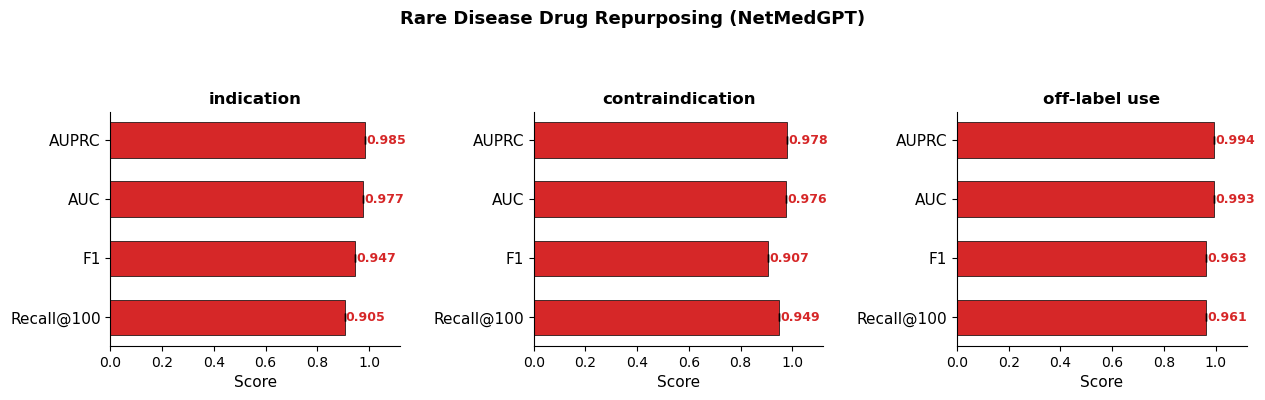

In [31]:
metrics       = ["auprc", "auc", "f1", "recall_100"]
METRIC_LABELS = {"auprc": "AUPRC", "auc": "AUC", "f1": "F1", "recall_100": "Recall@100"}
NM_COLOR      = "#D62728"

fig, axes = plt.subplots(1, len(edge_types), figsize=(13, 4), sharey=False)

for ax, edge in zip(axes, edge_types):
    means  = [rd_data[m][edge][0] for m in metrics]
    stds   = [rd_data[m][edge][1] for m in metrics]
    labels = [METRIC_LABELS[m]    for m in metrics]

    y_pos = np.arange(len(metrics))
    ax.barh(y_pos, means, xerr=stds, color=NM_COLOR,
            capsize=3, edgecolor="black", linewidth=0.5, height=0.6)

    for yi, (m, s) in enumerate(zip(means, stds)):
        ax.text(m + s + 0.005, yi, f"{m:.3f}", va="center",
                fontsize=9, color=NM_COLOR, fontweight="bold")

    ax.set_yticks(y_pos)
    ax.set_yticklabels(labels, fontsize=11)
    ax.invert_yaxis()
    ax.set_xlim(0, 1.12)
    ax.set_xlabel("Score", fontsize=11)
    ax.set_title(edge, fontsize=12, fontweight="bold", pad=6)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.grid(False)

fig.suptitle("Rare Disease Drug Repurposing (NetMedGPT)",
             fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout(pad=2.0)

out_png = os.path.join(data_dir, "rare_disease_netmedgpt.png")
out_pdf = os.path.join(data_dir, "rare_disease_netmedgpt.pdf")
plt.savefig(out_png, bbox_inches="tight", dpi=300)
plt.savefig(out_pdf, bbox_inches="tight", dpi=300)
print(f"Saved: {out_png}")
plt.show()

Saved: /home/bbc8731/NetMedGPT/reproduce_plots/results/rare_disease_netmedgpt_no_text.png


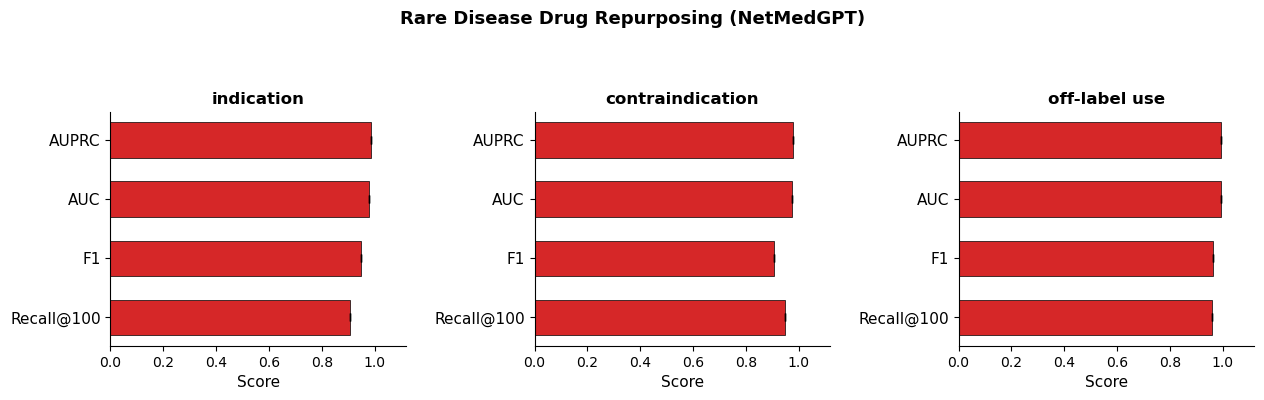

In [32]:
fig2, axes2 = plt.subplots(1, len(edge_types), figsize=(13, 4), sharey=False)

for ax, edge in zip(axes2, edge_types):
    means  = [rd_data[m][edge][0] for m in metrics]
    stds   = [rd_data[m][edge][1] for m in metrics]
    labels = [METRIC_LABELS[m]    for m in metrics]

    y_pos = np.arange(len(metrics))
    ax.barh(y_pos, means, xerr=stds, color=NM_COLOR,
            capsize=3, edgecolor="black", linewidth=0.5, height=0.6)

    ax.set_yticks(y_pos)
    ax.set_yticklabels(labels, fontsize=11)
    ax.invert_yaxis()
    ax.set_xlim(0, 1.12)
    ax.set_xlabel("Score", fontsize=11)
    ax.set_title(edge, fontsize=12, fontweight="bold", pad=6)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.grid(False)

fig2.suptitle("Rare Disease Drug Repurposing (NetMedGPT)",
              fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout(pad=2.0)

out_png2 = os.path.join(data_dir, "rare_disease_netmedgpt_no_text.png")
out_pdf2 = os.path.join(data_dir, "rare_disease_netmedgpt_no_text.pdf")
plt.savefig(out_png2, bbox_inches="tight", dpi=300)
plt.savefig(out_pdf2, bbox_inches="tight", dpi=300)
print(f"Saved: {out_png2}")
plt.show()